<a href="https://colab.research.google.com/github/hilalanas20/ML-Based-Prediction-of-Eating-Disorders/blob/main/Copy_of_ML_Based_Prediction_of_Eating_Disorders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Load the dataset
df1 = pd.read_csv("1- mental-illnesses-prevalence.csv")

# Rename columns for easier use
df1 = df1.rename(columns={
    df1.columns[3]: 'Schizophrenia disorders',
    df1.columns[4]: 'Depressive disorders',
    df1.columns[5]: 'Anxiety disorders',
    df1.columns[6]: 'Bipolar disorders',
    df1.columns[7]: 'Eating disorders'
})


In [ ]:
# Select input features and target
X = df1[['Schizophrenia disorders', 'Depressive disorders', 'Anxiety disorders', 'Bipolar disorders']]
y = df1['Eating disorders']

# Add polynomial features (squared)
X['Schizophrenia_sq'] = X['Schizophrenia disorders'] ** 2
X['Depressive_sq'] = X['Depressive disorders'] ** 2
X['Anxiety_sq'] = X['Anxiety disorders'] ** 2
X['Bipolar_sq'] = X['Bipolar disorders'] ** 2

# Add interaction features
X['DepxAnx'] = X['Depressive disorders'] * X['Anxiety disorders']
X['SchizoxBipolar'] = X['Schizophrenia disorders'] * X['Bipolar disorders']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌲 Random Forest Evaluation")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


🌲 Random Forest Evaluation
MAE: 0.00318828819646677
MSE: 6.999563189033657e-05
RMSE: 0.00836633921678631
R² Score: 0.9964965255004548


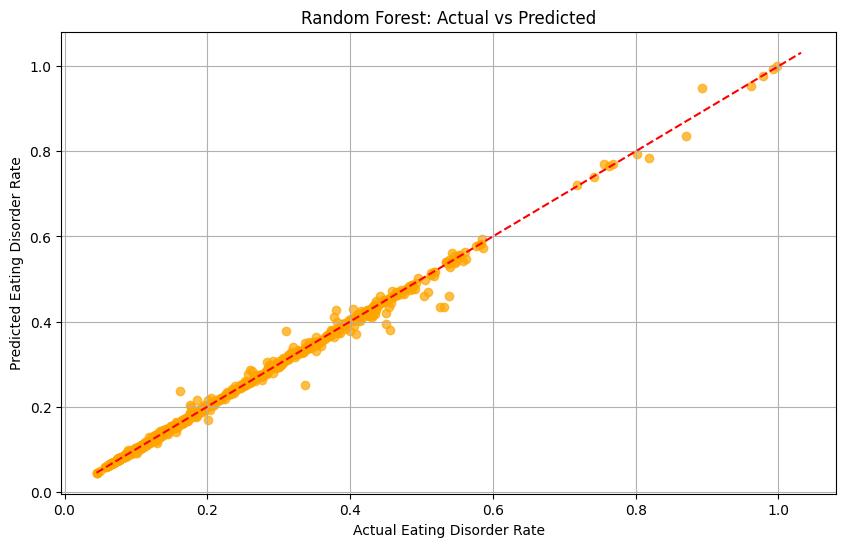

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='orange', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Eating Disorder Rate")
plt.ylabel("Predicted Eating Disorder Rate")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()
